# **1-Importing needed libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

# 2-**Importing** the Dataset from google drive

In [ ]:
url = "https://drive.google.com/file/d/1TFMH6JiPupw-I0VxZaq4ciwH1VQTO9es/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
songs_df = pd.read_csv(path)
# Create a Pandas DataFrame from the CSV data
songs_df

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.6580,0.25900,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.3060,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.7420,0.39900,2,-12.646,1,0.0346,0.217,0.000002,0.1070,0.6930,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.8510,0.73000,2,-11.048,1,0.3470,0.453,0.000063,0.1240,0.9050,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.7050,0.05020,4,-18.115,1,0.0471,0.879,0.000041,0.3860,0.5240,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.6510,0.11900,6,-19.807,1,0.0380,0.916,0.000343,0.1040,0.4020,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,5230,"1812 Festival Overture, Op. 49: 1812 Overture,...",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,3,-23.390,1,0.0473,0.917,0.715000,0.0832,0.0655,87.906,,995000,4,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...
5231,5231,"Winter Fragments pour ensemble instrumental, s...",Tristan Murail,0.1880,0.10100,6,-21.873,1,0.0442,0.855,0.426000,0.0694,0.0355,83.134,,855000,4,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...
5232,5232,"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3...",Arnold Schoenberg,0.0596,0.00093,9,-42.959,1,0.0434,0.951,0.969000,0.0772,0.0344,71.573,,238187,3,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...
5233,5233,"Serenade For Strings In E, Op.22, B. 52: 1. Mo...",Antonín Dvořák,0.1330,0.02080,4,-29.443,1,0.0419,0.883,0.505000,0.1110,0.0591,67.109,,314307,4,7ucDwgMtE3YJtEfTbuRhy0,https://open.spotify.com/track/7ucDwgMtE3YJtEf...


In [ ]:
songs_df.nunique()

,0
Unnamed: 0,5235
name,5011
artist,2176
danceability,882
energy,1191
key,12
loudness,4310
mode,2
speechiness,1001
acousticness,2545


In [ ]:
songs_df.drop_duplicates(inplace=True)

# 3-**Removing** the white spaces from the columnsnames and cleaning up the data

In [ ]:
songs_df.columns = songs_df.columns.str.replace(' ', '')

In [ ]:
songs_df=songs_df.drop(columns=['Unnamed:0'])
songs_df=songs_df.set_index('id')

In [ ]:
X = songs_df.drop(columns=['html', 'artist','type',	'name','key', 'mode','time_signature']).copy()
X

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
id,,,,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376,256213
5QGM1U0eCYrQuwSJwTm5Zq,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039,191867
0NLIFSZxPzQhCwnkn5PJYs,0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698,152267
3mXqOdlLE1k67WsAxryPFs,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802,186227
7bSzjzjTkWT2CkIPPdp0eA,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941,273680
...,...,...,...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906,995000
1Gfqe7TAKklmuZf6hxsH6h,0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134,855000
2XNwnFrdMDpismp0VUZ7cU,0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573,238187


# 4-**Apply** minmaxscaler on the dataset

In [ ]:
minmaxscaler = MinMaxScaler().set_output(transform="pandas")
X_scaled = minmaxscaler.fit_transform(X)
X_scaled.sample(10)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
id,,,,,,,,,,
4F4kA4FNEzyEX7QxbZr8Ko,0.562565,0.90800,0.850787,0.083224,0.003554,0.000119,0.240122,0.551269,0.602897,0.037240
48zi76YORvpiYO67liH70R,0.141675,0.94800,0.853705,0.111111,0.000003,0.516751,0.339412,0.309645,0.782513,0.050122
5jfTIrmADLt0seRX9rwtKq,0.714581,0.57400,0.880213,0.029521,0.118474,0.000071,0.140831,0.867005,0.500238,0.039818
02BumRY2OTFMkMxrXSVMat,0.387797,0.00406,0.459326,0.073094,0.997992,0.921827,0.085309,0.363452,0.652750,0.006774
0ofMkI3jzmGCElAOgOLeo3,0.713547,0.80500,0.790291,0.036601,0.000233,0.750254,0.096251,0.811168,0.597262,0.061200
7hDq6sOZ5Rl1XnSSfoOBRK,0.452947,0.18200,0.730185,0.036819,0.986948,0.853807,0.120567,0.064873,0.306253,0.066462
7bzE1Y56OWShf2970pBfYM,0.221303,0.17000,0.693244,0.058824,0.982932,0.016345,0.336373,0.047107,0.359587,0.107156
49RUdNvwSiUTC8fBh4KKoC,0.380558,0.40300,0.771103,0.031373,0.705823,0.000008,0.204661,0.343147,0.632665,0.047556
4tCtwWceOPWzenK2HAIJSb,0.830403,0.58500,0.882576,0.047059,0.103414,0.000004,0.065248,0.602030,0.490757,0.048036


In [ ]:
X_scaled.shape

(5235, 10)

# 5-**Finding** the proper number of klusters in the first round

**finding Inertia scoor**

In [ ]:
random_seed = 17
max_k= 20
inertia_list=[]
for i in range(2,max_k+1):
  kmeans=KMeans(i,random_state=random_seed)
  kmeans.fit(X_scaled)
  inertia_list.append(kmeans.inertia_)
inertia_list

[1907.8793407994856,
 1257.7020801114331,
 1046.1282413548454,
 819.277044213275,
 753.706639250954,
 717.8828644828982,
 681.2344006141916,
 651.811611289508,
 618.3829306564514,
 595.021589838469,
 580.0990359814845,
 564.3112722619533,
 544.7878297552215,
 529.9103981073564,
 521.1670174461343,
 505.85856115662074,
 496.8393713511779,
 487.792311306665,
 476.43183220935504]

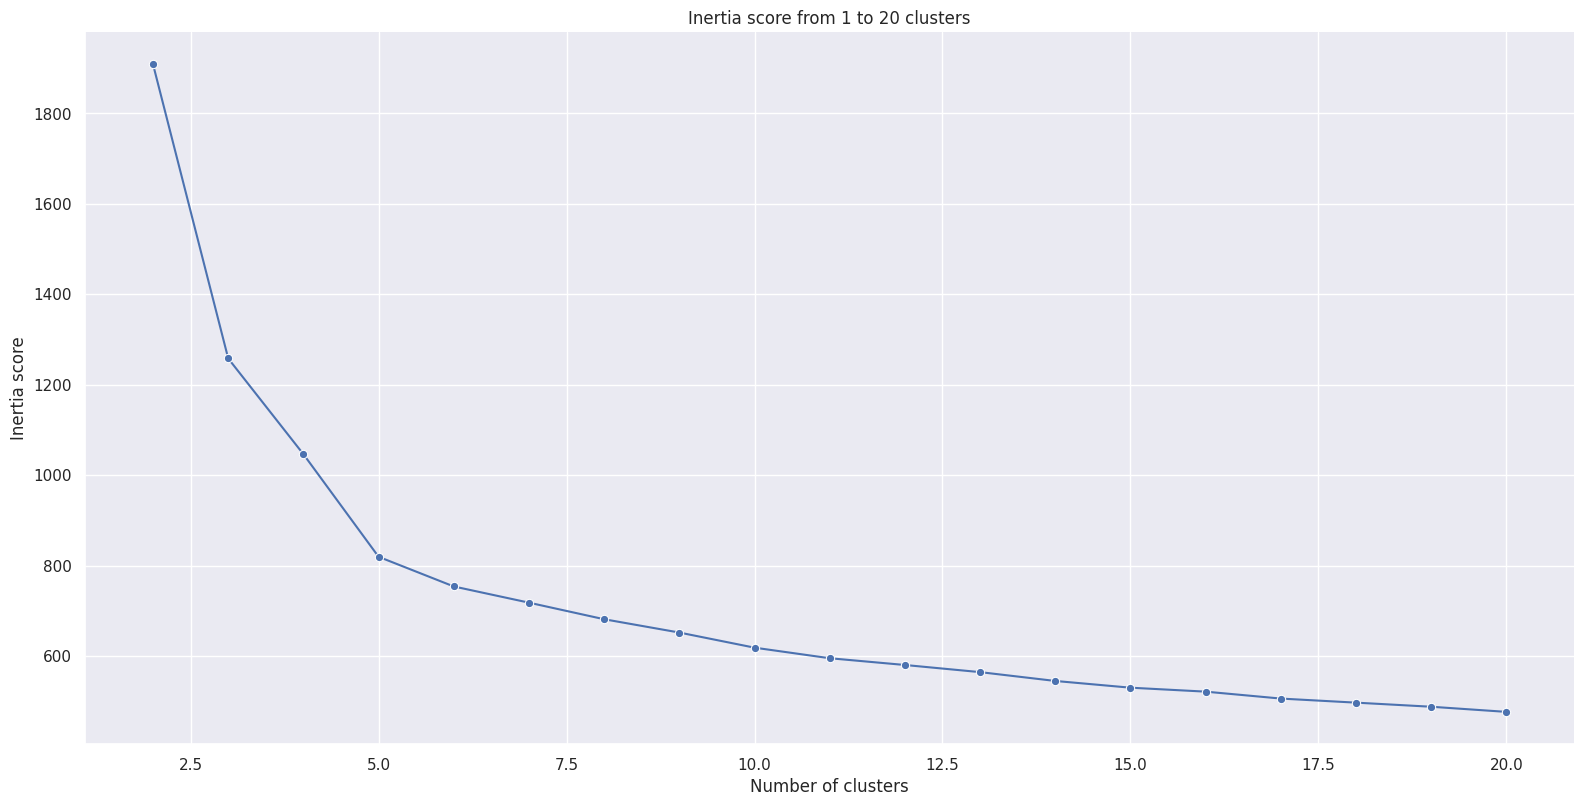

In [ ]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(2, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 1 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

*As we can see from this plot the first round of clustering should be 5 clusters, let's make sure of our result by see the silhouette scoor*




**finding silhouette score**

In [ ]:
random_seed =17
max_k= 25
silhouette_list=[]
for i in range(2,max_k+1):
  kmeans=KMeans(i,random_state=random_seed)
  kmeans.fit(X_scaled)
  labels=kmeans.labels_
  silhouette= silhouette_score(X_scaled,labels)
  silhouette_list.append(silhouette)
silhouette_list

[np.float64(0.5676604523280683),
 np.float64(0.5851578842693851),
 np.float64(0.603809669059891),
 np.float64(0.638337783127669),
 np.float64(0.45812801666081177),
 np.float64(0.368359895533034),
 np.float64(0.31600557476534763),
 np.float64(0.316559674849065),
 np.float64(0.3137736256425796),
 np.float64(0.31045519638613994),
 np.float64(0.25454258466571233),
 np.float64(0.25233032843336695),
 np.float64(0.20240622405617315),
 np.float64(0.2069705255030473),
 np.float64(0.20466045089322094),
 np.float64(0.19825024018464646),
 np.float64(0.19682767512365607),
 np.float64(0.19424451446787394),
 np.float64(0.1910158562575056),
 np.float64(0.17366084555960845),
 np.float64(0.17583731222730703),
 np.float64(0.173177182099261),
 np.float64(0.16981231534131752),
 np.float64(0.16773092146476115)]

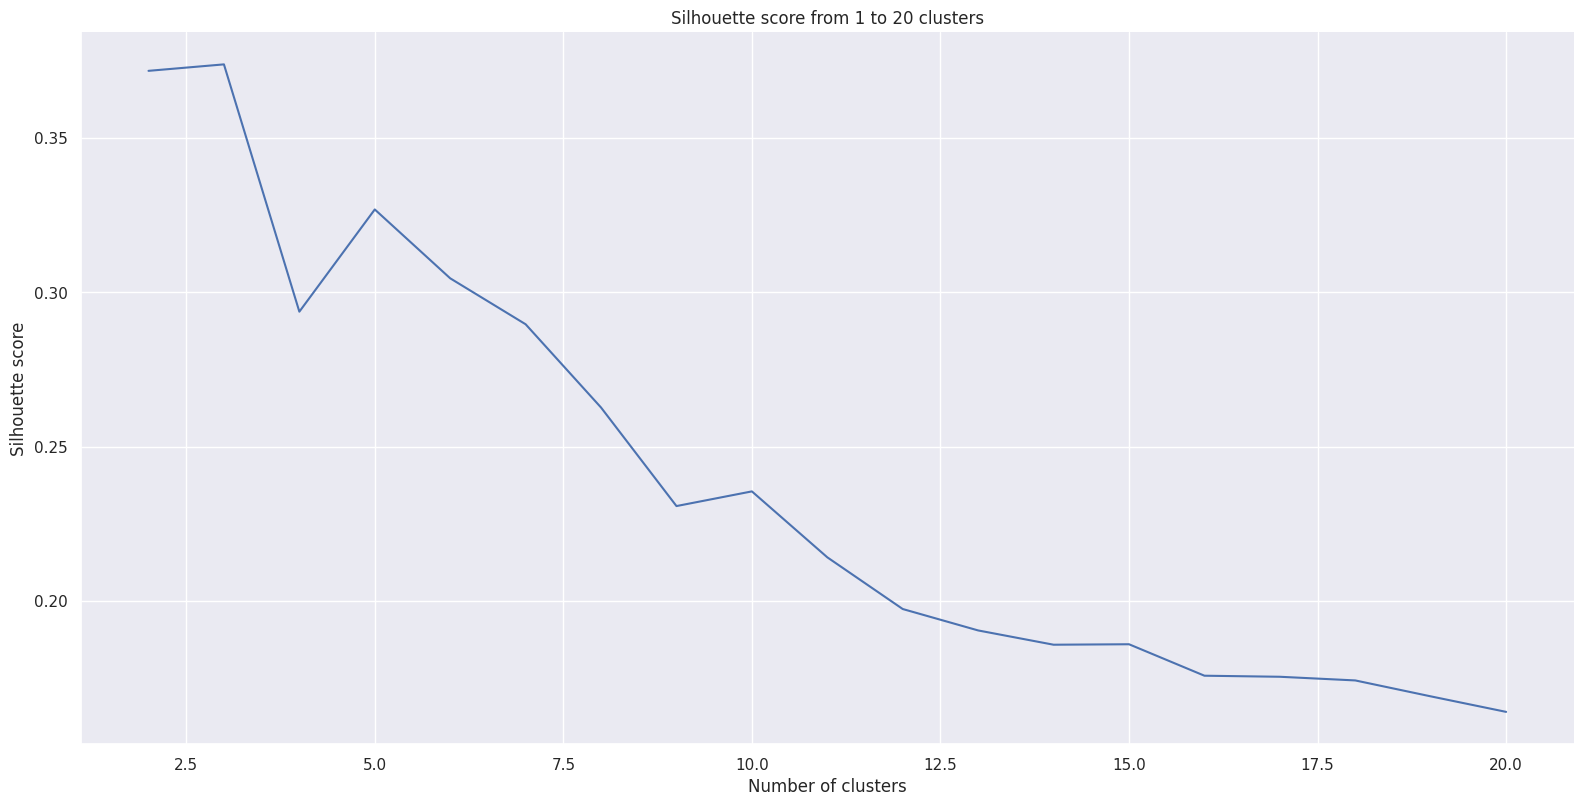

In [ ]:
sns.set_theme(style='darkgrid')
(
 sns.relplot(y= silhouette_list,
             x=range(2,max_k+1),
             height=8,
             aspect=2,
             kind='line',
             markers='o'
             )
 .set(title=f"Silhouette score from 1 to {max_k} clusters")
 .set_axis_labels("Number of clusters", "Silhouette score")

)

*This shows also that 5 is the best number of clusters for the first phase*

# **6- Working on 5 clusters**

In [ ]:
random_seed =17
kmeans=KMeans(5,verbose=1, random_state =random_seed)
kmeans.fit(X_scaled)
labels= kmeans.labels_
X_scaled['cluster']=labels
X_scaled

Initialization complete
Iteration 0, inertia 1567.379923683327.
Iteration 1, inertia 976.2029359381753.
Iteration 2, inertia 900.4342497189746.
Iteration 3, inertia 861.018776607422.
Iteration 4, inertia 836.1909198331293.
Iteration 5, inertia 825.4343208360092.
Iteration 6, inertia 821.867163266784.
Iteration 7, inertia 820.4068067052252.
Iteration 8, inertia 819.8095660011447.
Iteration 9, inertia 819.5250199250457.
Iteration 10, inertia 819.4170483779458.
Iteration 11, inertia 819.3163222588087.
Iteration 12, inertia 819.2840999194763.
Converged at iteration 12: center shift 5.161939813898664e-06 within tolerance 5.41313216236366e-06.


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
id,,,,,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,0.680455,0.25900,0.763897,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800,0.059067,4
5QGM1U0eCYrQuwSJwTm5Zq,0.767322,0.39900,0.771967,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322,0.042058,0
0NLIFSZxPzQhCwnkn5PJYs,0.880041,0.73000,0.798018,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862,0.031590,0
3mXqOdlLE1k67WsAxryPFs,0.729059,0.05020,0.682811,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098,0.040567,4
7bSzjzjTkWT2CkIPPdp0eA,0.673216,0.11900,0.655228,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171,0.063684,4
...,...,...,...,...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,0.208893,0.06940,0.596818,0.051525,0.920683,0.725888,0.084296,0.066497,0.410795,0.254357,3
1Gfqe7TAKklmuZf6hxsH6h,0.194416,0.10100,0.621548,0.048148,0.858434,0.432487,0.070314,0.036041,0.388495,0.217350,3
2XNwnFrdMDpismp0VUZ7cU,0.061634,0.00093,0.277803,0.047277,0.954819,0.983756,0.078217,0.034924,0.334469,0.054302,3


# **7- Dividing the Dataset into 5 datasets**

In [ ]:
X0= X_scaled.loc[X_scaled['cluster']==0].drop(columns=['cluster'])
X1= X_scaled.loc[X_scaled['cluster']==1].drop(columns=['cluster'])
X2= X_scaled.loc[X_scaled['cluster']==2].drop(columns=['cluster'])
X3= X_scaled.loc[X_scaled['cluster']==3].drop(columns=['cluster'])
X4= X_scaled.loc[X_scaled['cluster']==4].drop(columns=['cluster'])

# **8- Finding The Inertia list and the Silhouette score list for every subset to find the best number of clusters for each subset**

In [ ]:
datasets=[X0,X1,X2,X3,X4]
all_inertia = []
all_silhouette = []

for X in datasets:
    inertia_list = []
    silhouette_list = []

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_seed)
        kmeans.fit(X)

        inertia_list.append(kmeans.inertia_)
        silhouette_list.append(silhouette_score(X, kmeans.labels_))

    all_inertia.append(inertia_list)
    all_silhouette.append(silhouette_list)


# 9- **Ploting** the Inertia scores for the 5 datasets

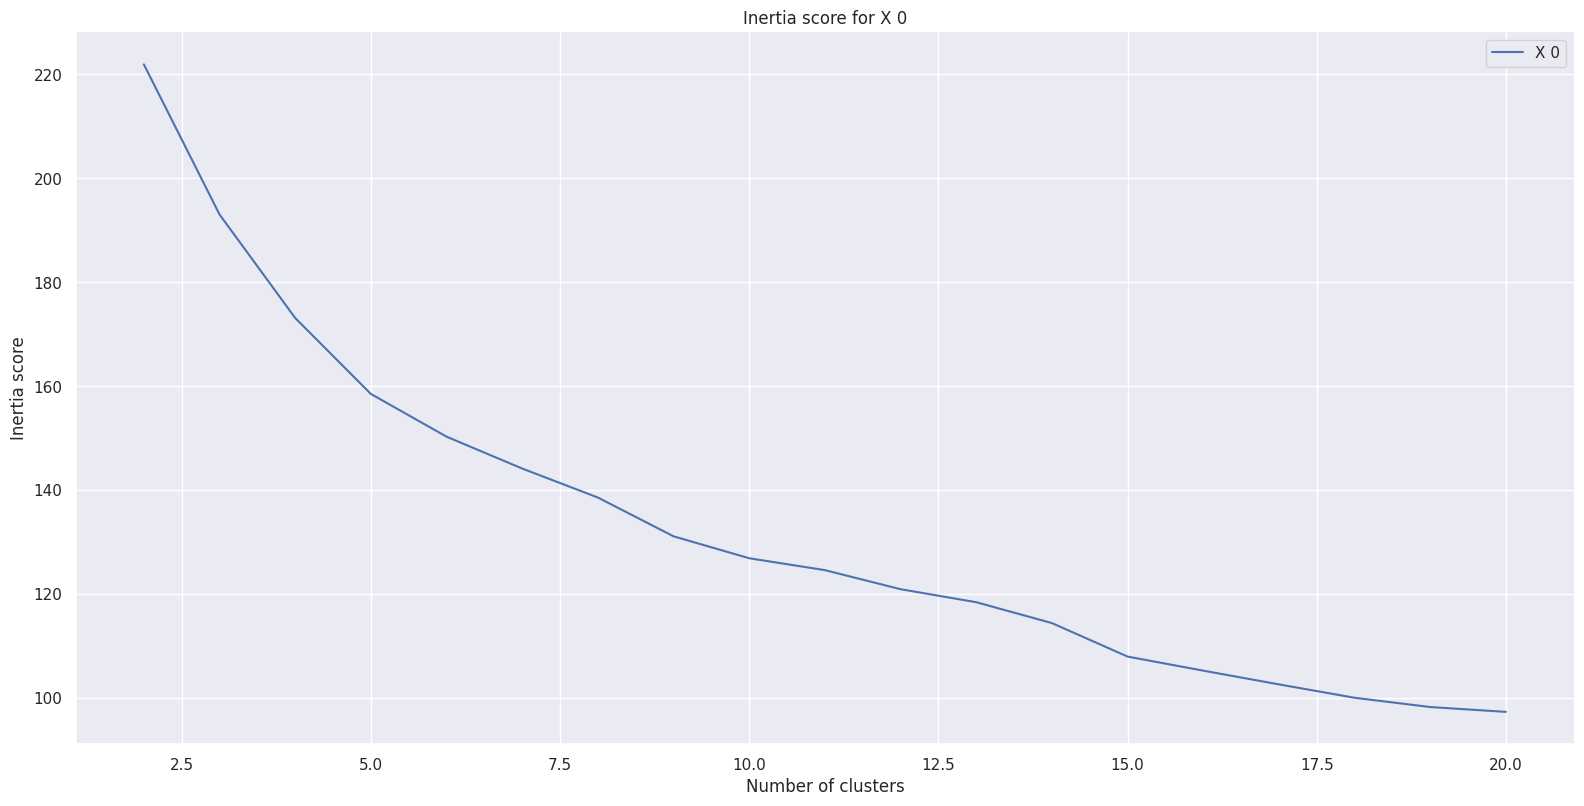

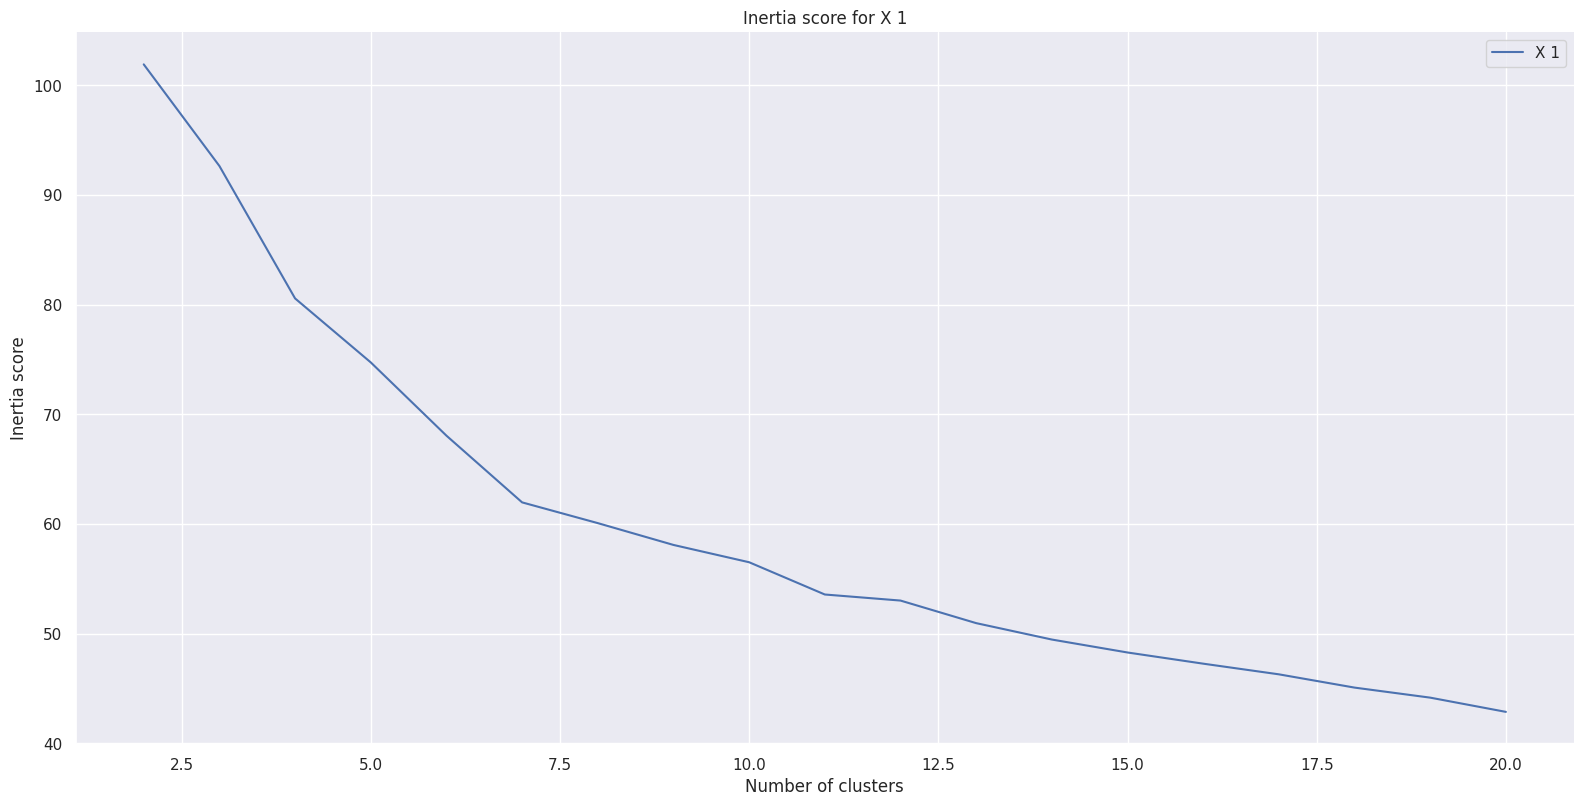

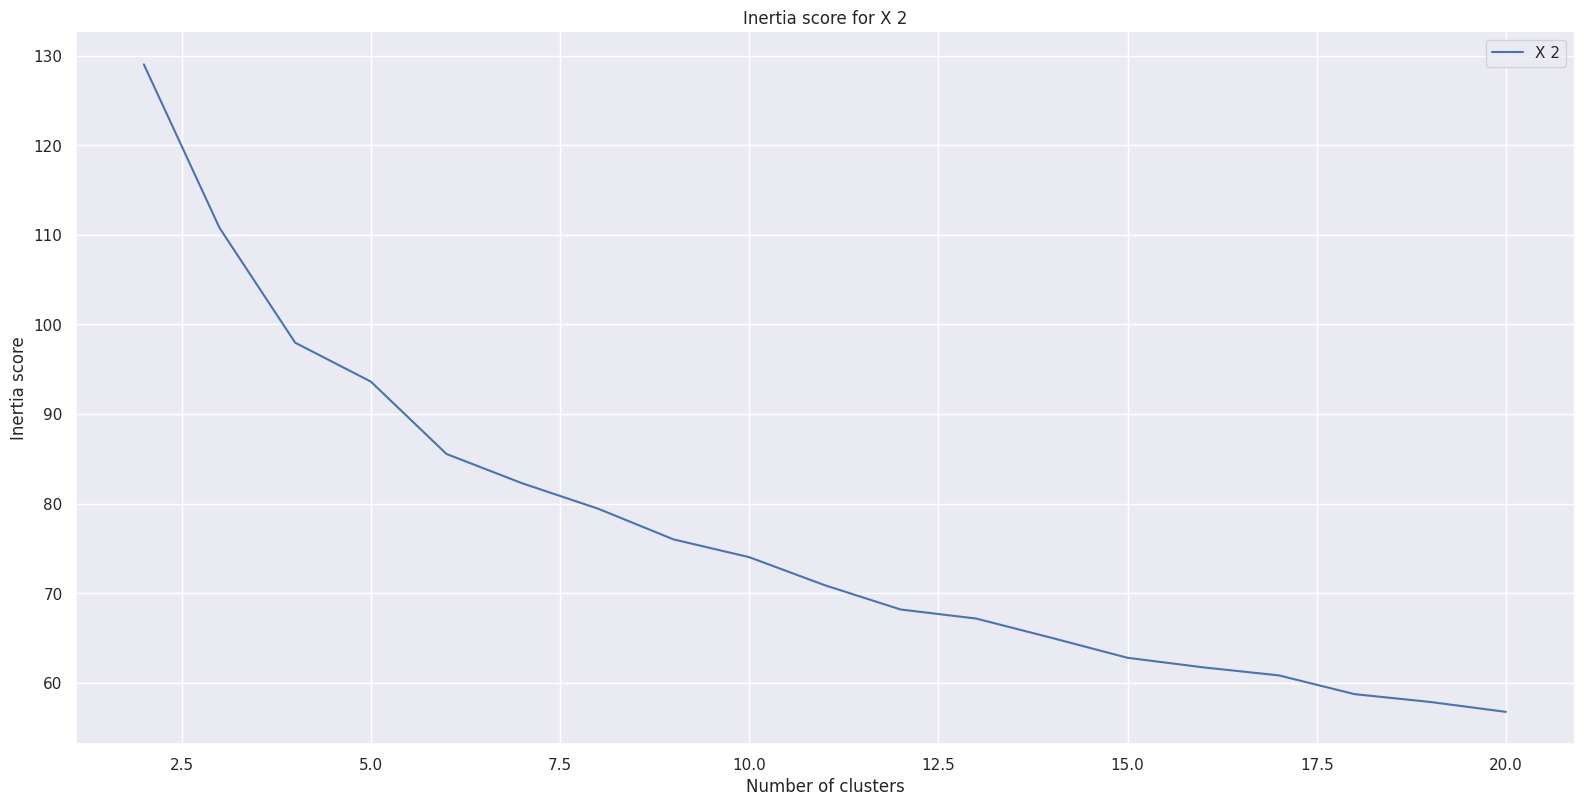

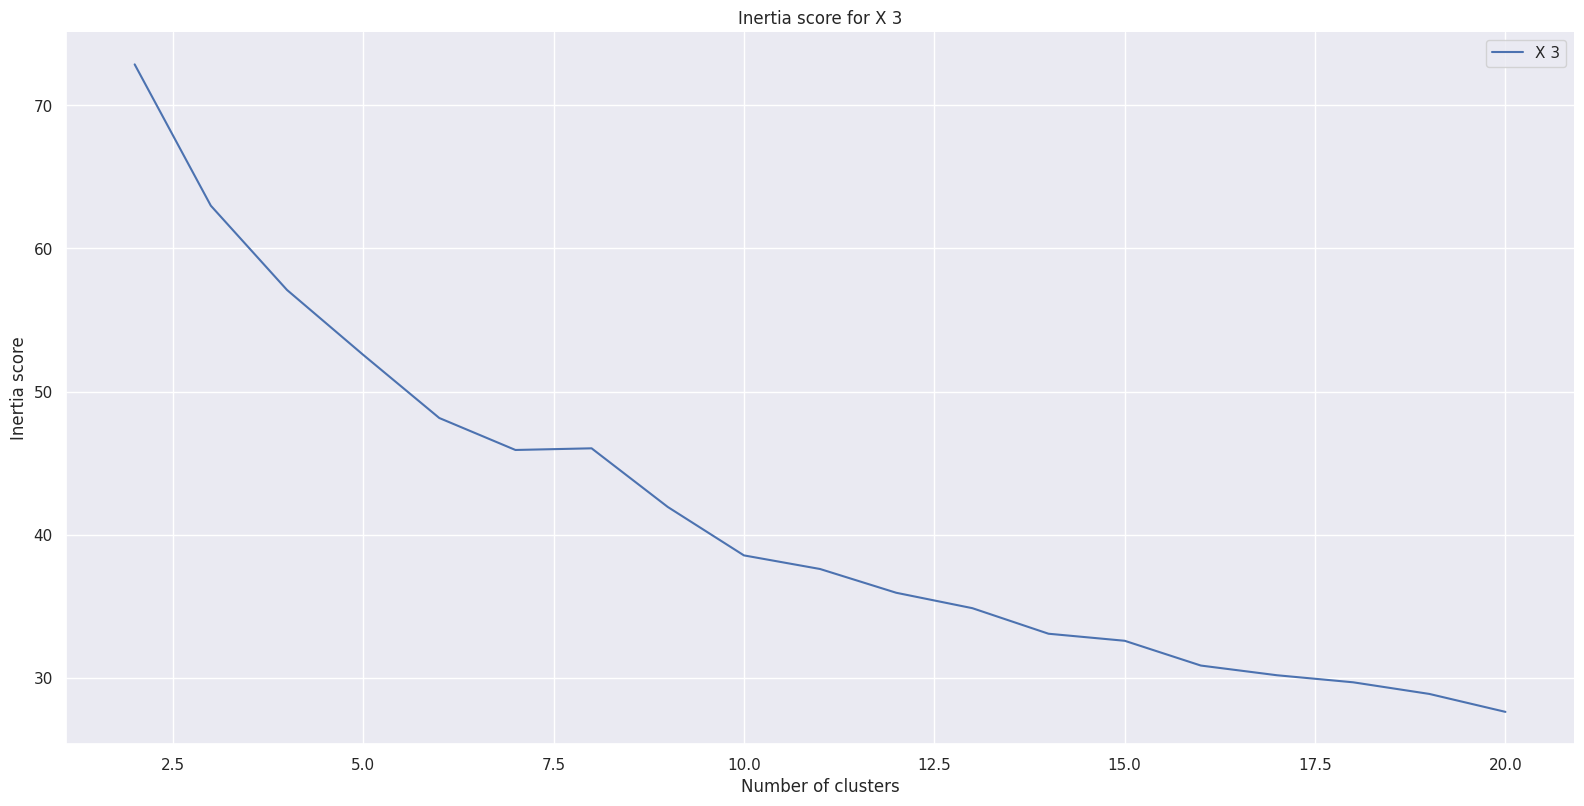

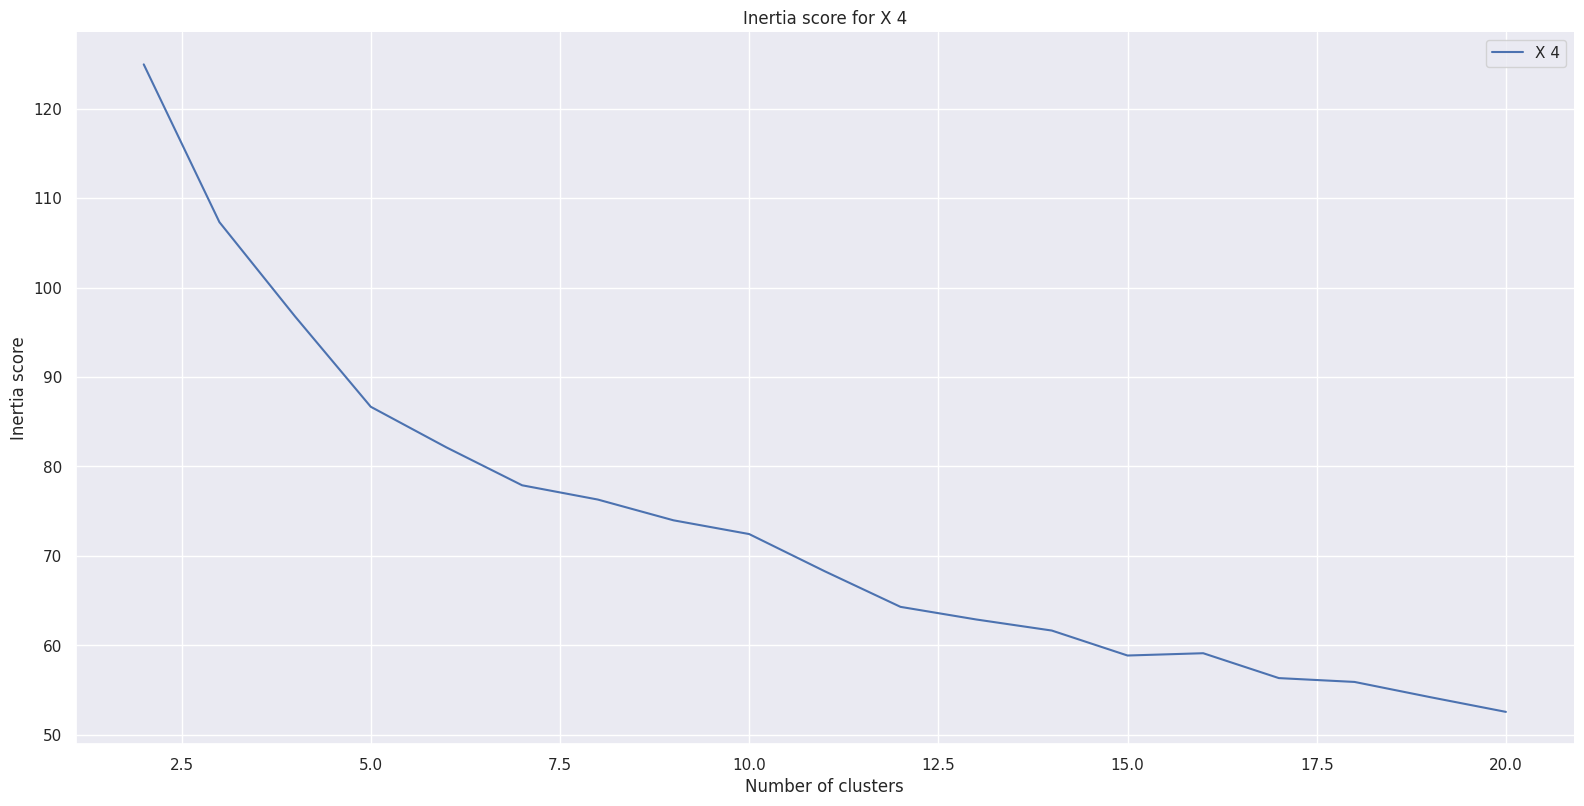

In [ ]:
for i in range(len(datasets)):
    sns.set_theme(style='darkgrid')
    sns.relplot(y=all_inertia[i],
                x=range(2, max_k + 1),
                height=8,
                aspect=2,
                kind='line',
                markers='o',
                label=f'X {i}')
    plt.title(f'Inertia score for X {i}')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia score')
    plt.legend()
    plt.show();

# **10- Ploting the Silhouette scores for the 5 datasets**

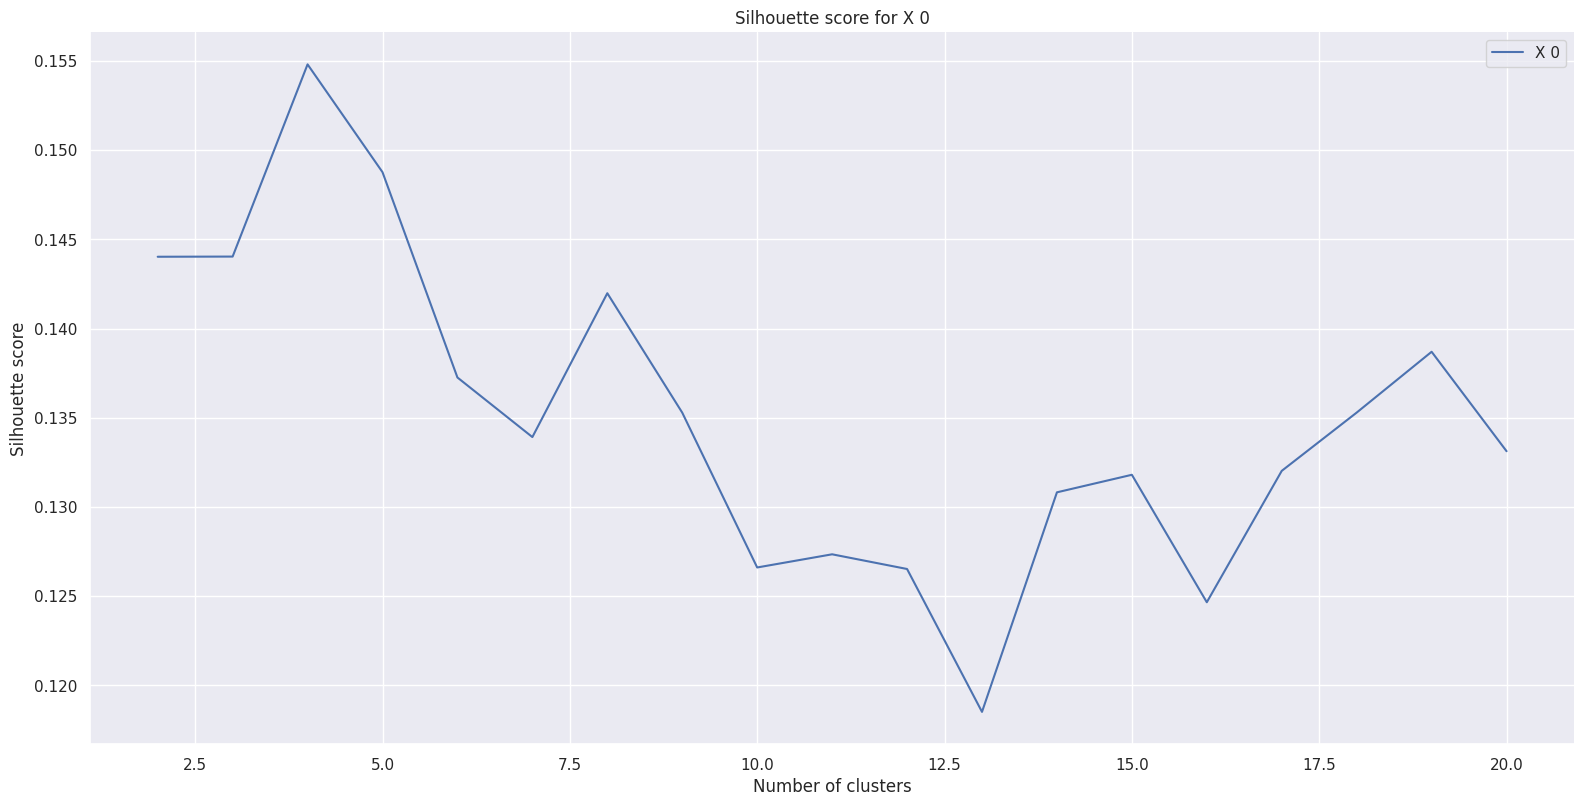

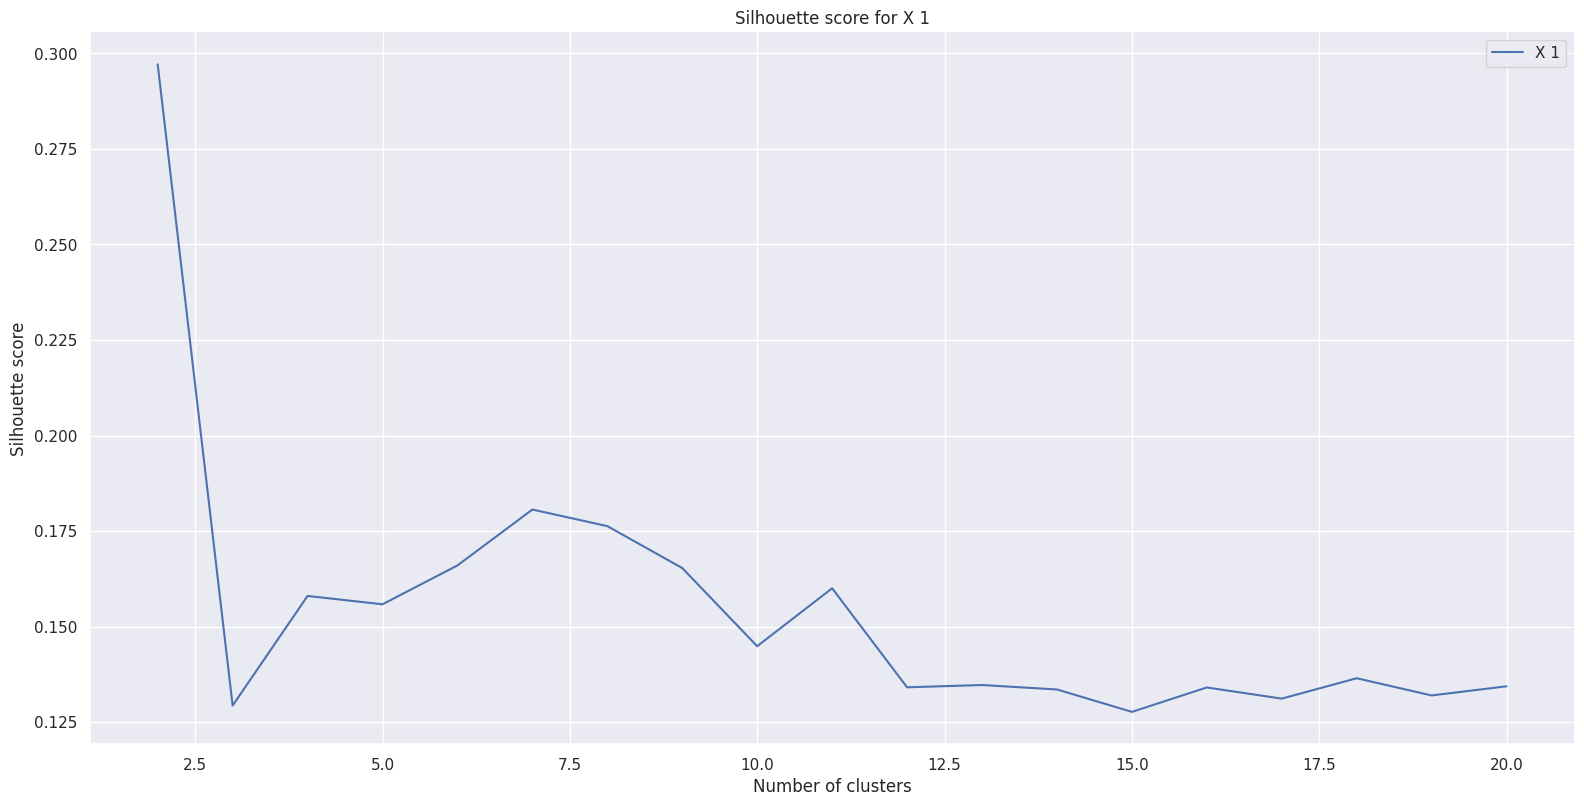

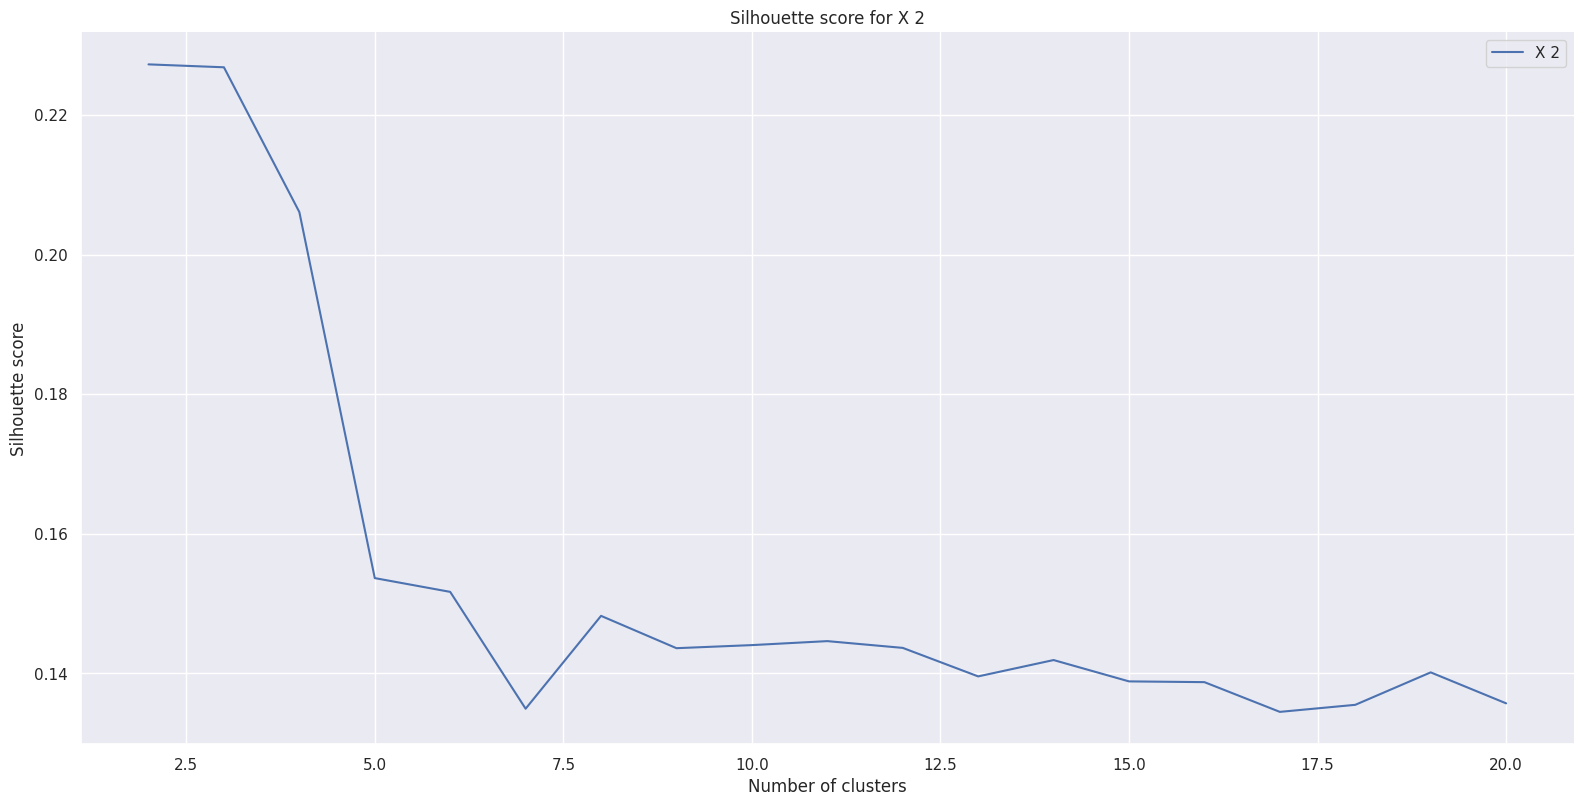

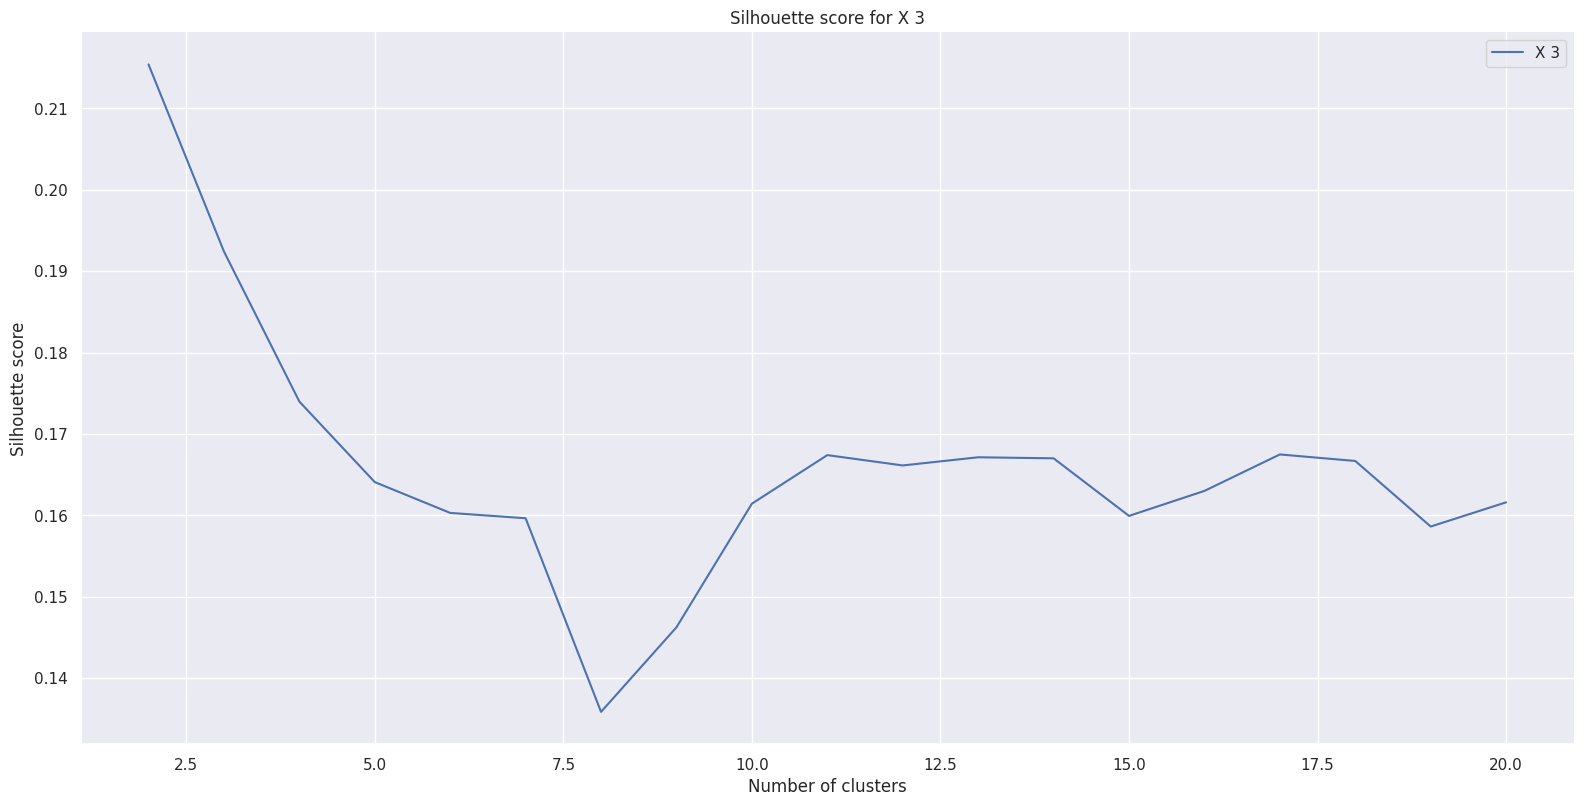

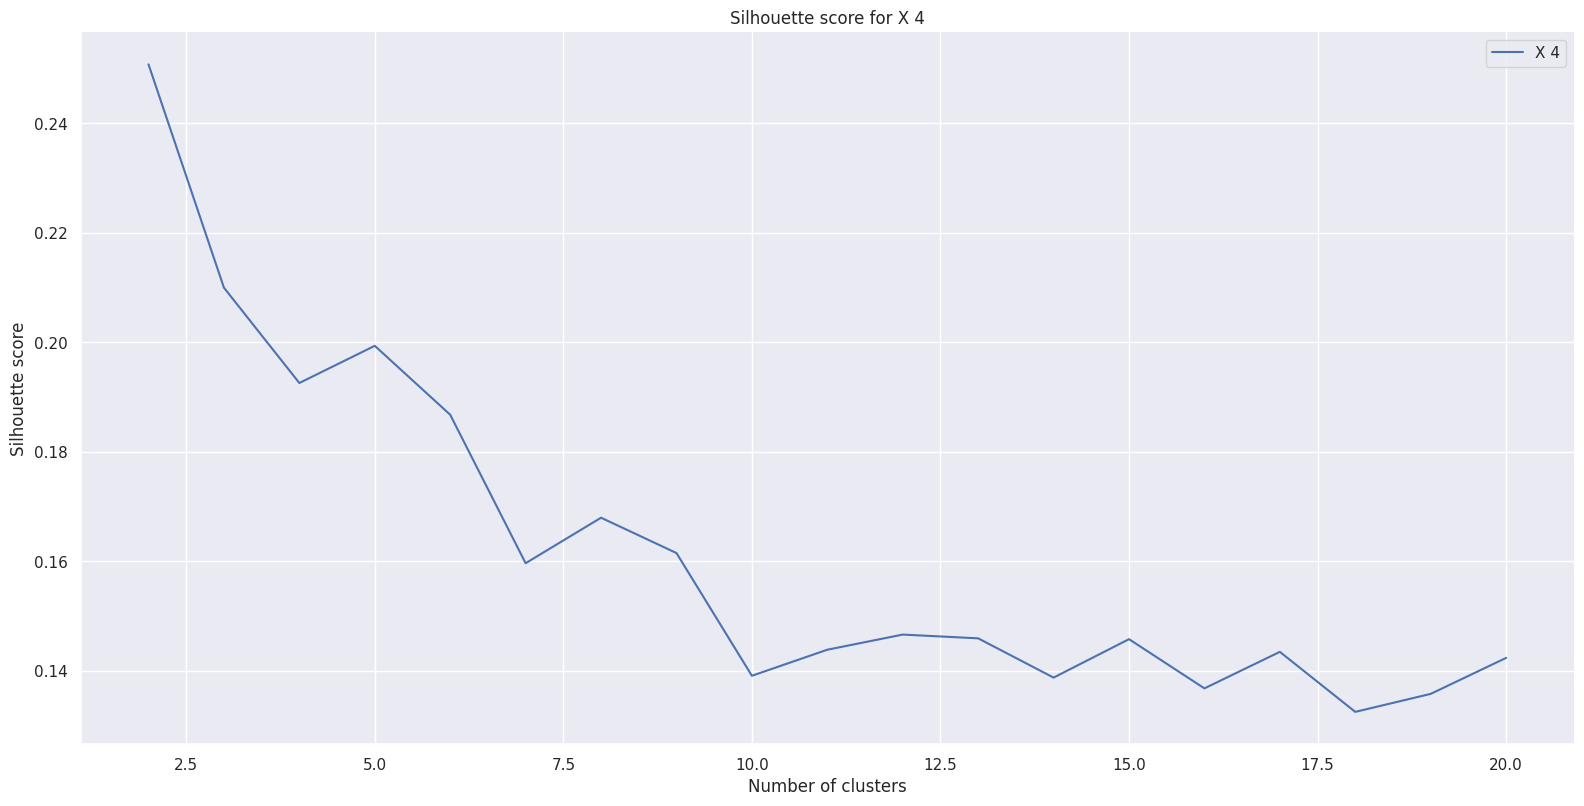

In [ ]:
for i in range(len(datasets)):
    sns.set_theme(style='darkgrid')
    sns.relplot(y=all_silhouette[i],
                x=range(2, max_k + 1),
                height=8,
                aspect=2,
                kind='line',
                markers='o',
                label=f'X {i}')
    plt.title(f'Silhouette score for X {i}')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette score')
    plt.legend()
    plt.show();

In [ ]:
for X in datasets:
    print(X.shape[0])

1799
891
1152
606
787


Depending to the analysis above I choose to cluster the datasets [X0,X1,X2,X3,X4] to these number of clusters [19,5,7,8,4] accordingly

# 11- Aplly the KMeans to the Datasets  [X0,X1,X2,X3,X4]

In [ ]:
def apply_kmeans(X,k, random_seed):
  kmeans=KMeans(k, random_state =random_seed)
  kmeans.fit(X)
  labels= kmeans.labels_
  X['cluster']=labels
  return X

In [ ]:
datasets=[X0,X1,X2,X3,X4]
clusters=[19,5,7,8,4]
random_seed =17
for k, X in zip(clusters,datasets):
   apply_kmeans(X,k, random_seed)

Initialization complete
Iteration 0, inertia 139.2552958298161.
Iteration 1, inertia 114.04331516389658.
Iteration 2, inertia 109.7026422713869.
Iteration 3, inertia 107.82569984248468.
Iteration 4, inertia 106.61030406904602.
Iteration 5, inertia 105.56055953680155.
Iteration 6, inertia 104.78228955796858.
Iteration 7, inertia 104.10978139737459.
Iteration 8, inertia 103.60204366848785.
Iteration 9, inertia 103.29521199130085.
Iteration 10, inertia 103.06398898492806.
Iteration 11, inertia 102.88172243563947.
Iteration 12, inertia 102.60992342277146.
Iteration 13, inertia 101.90952115045755.
Iteration 14, inertia 100.21644759202081.
Iteration 15, inertia 99.02638102697425.
Iteration 16, inertia 98.85815089335225.
Iteration 17, inertia 98.80896600010657.
Iteration 18, inertia 98.78578151758484.
Iteration 19, inertia 98.77013071548272.
Iteration 20, inertia 98.75723070051689.
Iteration 21, inertia 98.7406351417222.
Iteration 22, inertia 98.72374754202757.
Iteration 23, inertia 98.719019

In [ ]:
all_playlists=[]
for k, X in zip(clusters,datasets):
  playlists=[]
  for i in range(k):
    p=X.loc[X['cluster']==i]
    playlists.append(p)
  all_playlists.append(playlists)

In [ ]:
for i in all_playlists:
  for X in i:
    print(X.shape)

(94, 11)
(35, 11)
(73, 11)
(117, 11)
(57, 11)
(35, 11)
(174, 11)
(95, 11)
(100, 11)
(88, 11)
(26, 11)
(99, 11)
(217, 11)
(118, 11)
(69, 11)
(101, 11)
(103, 11)
(148, 11)
(50, 11)
(154, 11)
(143, 11)
(297, 11)
(162, 11)
(135, 11)
(86, 11)
(159, 11)
(200, 11)
(111, 11)
(202, 11)
(228, 11)
(166, 11)
(106, 11)
(33, 11)
(69, 11)
(62, 11)
(25, 11)
(100, 11)
(106, 11)
(105, 11)
(206, 11)
(172, 11)
(199, 11)
(210, 11)


The results are not acceptable because the don't fall into the rang (50,250) so KMeans is not a proper model to apply to our project.
The best model in our case is KMeansConstrained, this model gives us the ability to control the sizes of the clusters.

# **12- Repeating everything using KMeansConstrained:**

In [ ]:
!pip install k-means-constrained

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.

In [ ]:
#from k_means_constrained import KMeansConstrained
#random_seed = 17
#max_k= 100
#inertia_listN=[]
#silhouette_listN=[]
#for i in range(21,max_k+1):
#  kmeans=KMeansConstrained(i,size_min=50, size_max=250,random_state=random_seed)
#  kmeans.fit(X_scaled)
#  inertia_listN.append(kmeans.inertia_)
#  labels=kmeans.labels_
#  silhouette= silhouette_score(X_scaled,labels)
#  silhouette_listN.append(silhouette)

In [ ]:
len(inertia_listN), len(silhouette_listN), len(range(21,101)), len(range(21,max_k+1))

(80, 80, 80, 5)

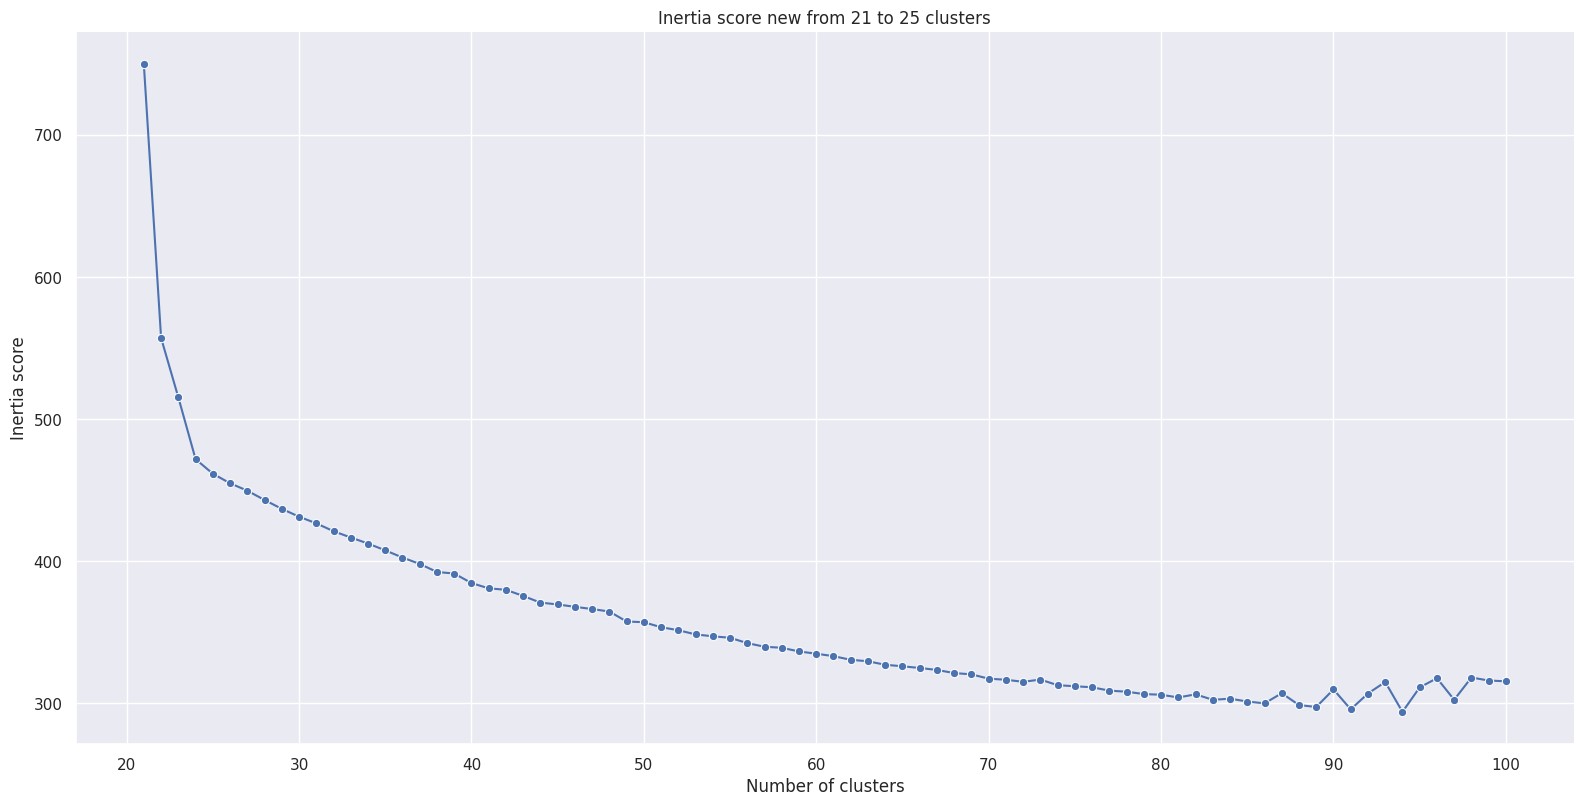

In [ ]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_listN,
            x = range(21, 101),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score new from 21 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

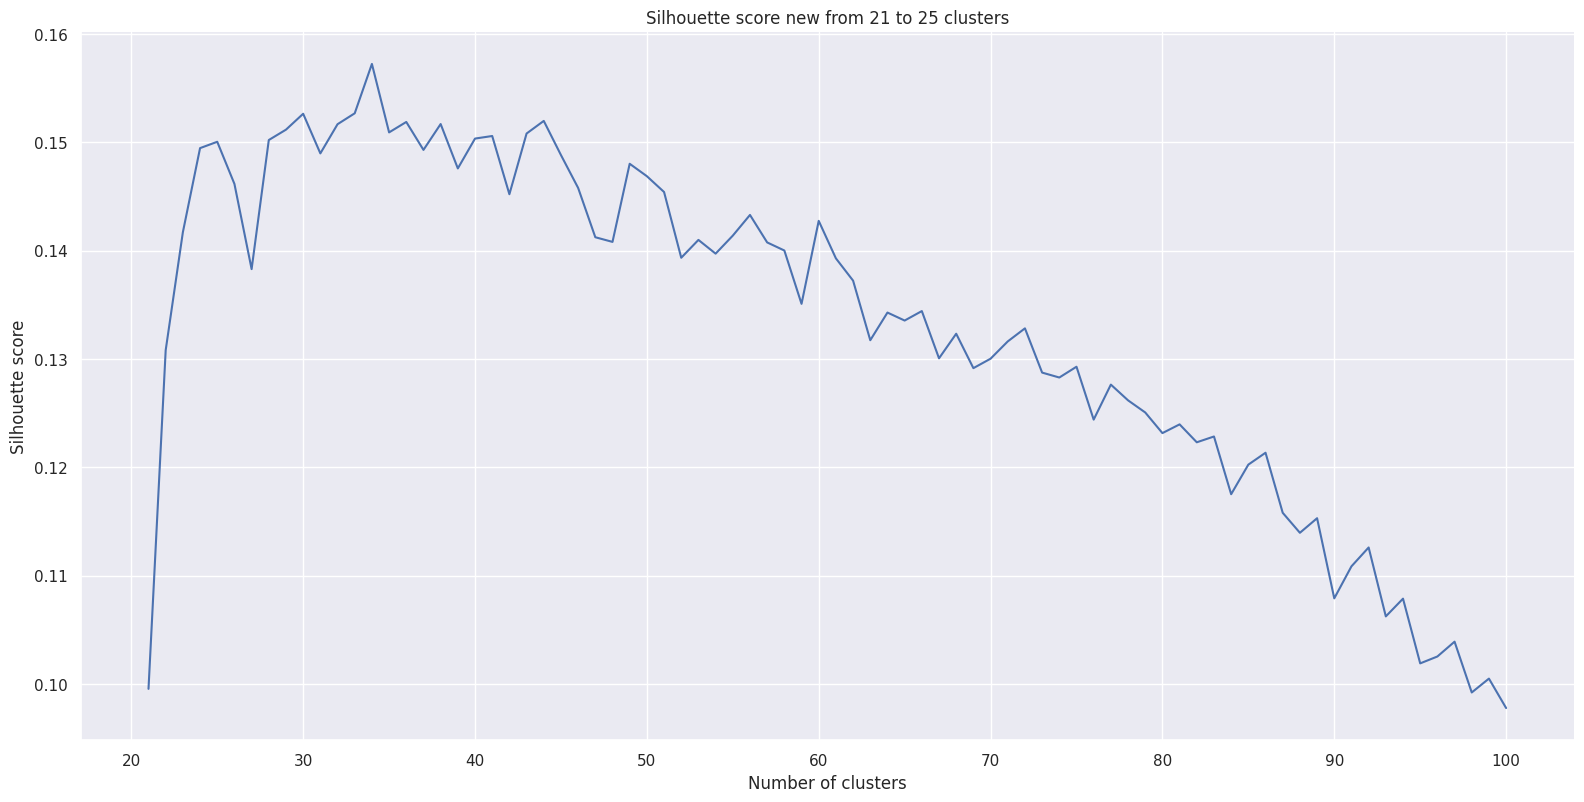

In [ ]:
sns.set_theme(style='darkgrid')
(
 sns.relplot(y= silhouette_listN,
             x=range(21,101),
             height=8,
             aspect=2,
             kind='line',
             markers='o'
             )
 .set(title=f"Silhouette score new from 21 to {max_k} clusters")
 .set_axis_labels("Number of clusters", "Silhouette score")

)

# **13- Selecting the best n_clusters = 45**

In [ ]:
kmeans=KMeansConstrained(45,size_min=50, size_max=250,random_state=random_seed)
kmeans.fit(X_scaled)
labels=kmeans.labels_
X_scaled['clusterN']=labels
X_scaled

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster,clusterN
id,,,,,,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,0.680455,0.25900,0.763897,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800,0.059067,4,31
5QGM1U0eCYrQuwSJwTm5Zq,0.767322,0.39900,0.771967,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322,0.042058,0,2
0NLIFSZxPzQhCwnkn5PJYs,0.880041,0.73000,0.798018,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862,0.031590,0,12
3mXqOdlLE1k67WsAxryPFs,0.729059,0.05020,0.682811,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098,0.040567,4,1
7bSzjzjTkWT2CkIPPdp0eA,0.673216,0.11900,0.655228,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171,0.063684,4,24
...,...,...,...,...,...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,0.208893,0.06940,0.596818,0.051525,0.920683,0.725888,0.084296,0.066497,0.410795,0.254357,3,32
1Gfqe7TAKklmuZf6hxsH6h,0.194416,0.10100,0.621548,0.048148,0.858434,0.432487,0.070314,0.036041,0.388495,0.217350,3,32
2XNwnFrdMDpismp0VUZ7cU,0.061634,0.00093,0.277803,0.047277,0.954819,0.983756,0.078217,0.034924,0.334469,0.054302,3,4


In [ ]:
playlists=[]
for i in range(45):
  p=X_scaled.loc[X_scaled['clusterN']==i]
  playlists.append(p)

# **14- Choosing 3 playlists to show up**

In [ ]:
import random
random_playlists = random.sample(playlists, 3)
playlist_1 = random_playlists[0]
playlist_2 = random_playlists[1]
playlist_3 = random_playlists[2]

In [ ]:
playlist_3

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster,clusterN
id,,,,,,,,,,,,
1jalG6lS08Gu8q16MgDbrC,0.234747,0.995,0.895863,0.235294,0.002440,0.304569,0.255319,0.213198,0.792317,0.027908,2,16
6nndigGeN6q17URSgwA7ks,0.321613,0.867,0.893352,0.087146,0.047390,0.000070,0.095542,0.093299,0.613253,0.065136,2,16
698mT3CTx8JEnp7twwJrGG,0.360910,0.913,0.919386,0.075272,0.030422,0.000008,0.121581,0.228426,0.766414,0.067424,2,16
0eGsygTp906u18L0Oimnem,0.362978,0.928,0.917642,0.082680,0.001135,0.000000,0.100101,0.242640,0.691761,0.050044,2,16
61mWefnWQOLf90gepjOCb3,0.366081,0.982,0.928793,0.183007,0.000238,0.000298,0.206687,0.196954,0.671863,0.058116,2,16
...,...,...,...,...,...,...,...,...,...,...,...,...
6rQ3jdwM3mVtKMfFOQmk7L,0.353671,0.991,0.878908,0.169935,0.002771,0.000243,0.228977,0.111675,0.592659,0.065313,2,16
0wn5YGy522pjLjjb6zZL8i,0.213030,0.989,0.892097,0.126362,0.000017,0.077259,0.061499,0.206091,0.750339,0.037744,2,16
6RtABrs34gtTEoLwTCsedx,0.218201,0.941,0.840957,0.076688,0.000100,0.027208,0.178318,0.259898,0.786635,0.078336,2,16


In [ ]:
#from google.colab import files
#playlist_1.to_csv('playlist_1.csv')
#playlist_2.to_csv('playlist_2.csv')
#playlist_3.to_csv('playlist_3.csv')
#files.download('playlist_1.csv')
#files.download('playlist_2.csv')
#files.download('playlist_3.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **15- Adding weights to some features to get more accurate results, and wraping everything in a function**

In [ ]:
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

In [ ]:
def weighted_clusters(X, feature_weights, k=45, size_min=50, size_max=250, random_state=17):
    X_weighted = X.copy()
    for feature, weight in feature_weights.items():
        if feature in X_weighted.columns:
          X_weighted[feature] *= weight
    model = KMeansConstrained(n_clusters=k, size_min=size_min, size_max= size_max, random_state= random_state)
    model.fit(X_weighted)
    X_weighted['cluster'] = model.labels_
    return X_weighted, model, silhouette_score(X_weighted, model.labels_), model.inertia_

# creating a dictionary to define the weights of the features

In [ ]:
feature_weights = {
    'danceability': 1.2,
    'energy': 1.0,
    'valence': 1.0,
    'acousticness': 1.5,
    'instrumentalness': 1.5,
    'speechiness': 0.8,
    'liveness': 0.7,
    'tempo': 1.0,
    'loudness': 0.8,
    'duration_ms': 0.5
}

clustered_df, model, silhouette_score, inertia = weighted_clusters(X_scaled, feature_weights)

In [ ]:
clustered_df

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
id,,,,,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,0.816546,0.25900,0.611118,0.061438,1.045181,0.000089,0.691489,0.310660,0.515800,0.029534,31
5QGM1U0eCYrQuwSJwTm5Zq,0.920786,0.39900,0.617574,0.030153,0.326807,0.000003,0.075887,0.703553,0.584322,0.021029,7
0NLIFSZxPzQhCwnkn5PJYs,1.056050,0.73000,0.638414,0.302397,0.682229,0.000097,0.087943,0.918782,0.437862,0.015795,16
3mXqOdlLE1k67WsAxryPFs,0.874871,0.05020,0.546249,0.041046,1.323795,0.000062,0.273759,0.531980,0.499098,0.020284,2
7bSzjzjTkWT2CkIPPdp0eA,0.807859,0.11900,0.524182,0.033115,1.379518,0.000522,0.073759,0.408122,0.565171,0.031842,2
...,...,...,...,...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,0.250672,0.06940,0.477454,0.041220,1.381024,1.088832,0.059007,0.066497,0.410795,0.127179,22
1Gfqe7TAKklmuZf6hxsH6h,0.233299,0.10100,0.497238,0.038519,1.287651,0.648731,0.049220,0.036041,0.388495,0.108675,39
2XNwnFrdMDpismp0VUZ7cU,0.073961,0.00093,0.222243,0.037821,1.432229,1.475635,0.054752,0.034924,0.334469,0.027151,22


# Selecting 2 playlists randomly

In [ ]:
playlists_weighted=[]
for i in range(45):
  p=clustered_df.loc[clustered_df['cluster']==i]
  playlists_weighted.append(p)

In [ ]:
import random
random_playlists = random.sample(playlists_weighted, 2)
playlist_1 = random_playlists[0]
playlist_2 = random_playlists[1]
#playlist_3 = random_playlists[2]
#playlist_1= cluster 4
#playlist_2= cluster 22

# *16- Creating a data frame of the centoids of the clusters **

In [ ]:
feature_col= clustered_df.columns.tolist()
feature_col.remove('cluster')

In [ ]:
centroids=pd.DataFrame(model.cluster_centers_, columns=feature_col)

In [ ]:
centroids

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.550738,0.860788,0.710502,0.086340,0.047951,0.021344,0.137997,0.686487,0.665801,0.024777
1,0.290199,0.308428,0.563900,0.041070,1.213494,1.325939,0.117970,0.105888,0.435930,0.041715
2,0.646189,0.199149,0.595944,0.040632,1.341103,0.028456,0.129557,0.339005,0.518259,0.026574
3,0.233253,0.920907,0.673686,0.092727,0.003400,1.330292,0.142208,0.210188,0.758155,0.030796
4,0.889291,0.846468,0.711883,0.061023,0.122016,0.011729,0.117095,0.865555,0.544972,0.024899
5,0.436707,0.529139,0.672283,0.041853,0.813035,0.013088,0.139875,0.333042,0.630927,0.030326
6,0.342397,0.952886,0.699500,0.119285,0.003805,0.048472,0.134340,0.164798,0.485394,0.029820
7,0.813959,0.527873,0.645786,0.045714,0.402045,0.013568,0.111040,0.840471,0.539099,0.023916
8,0.459207,0.069967,0.454748,0.042890,1.479575,1.382048,0.073773,0.149246,0.364280,0.026308
9,0.370285,0.869109,0.660114,0.068539,0.008418,1.313488,0.133875,0.413806,0.529197,0.028162


# **17- Pairwise distances of centroids and heatmap**

In [ ]:
from sklearn.metrics import pairwise_distances

In [ ]:
centers_distances =pd.DataFrame(pairwise_distances(centroids, metric='euclidean'), columns=range(45), index=range(45))

In [ ]:
centers_distances

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
0,0.000000,1.961532,1.508964,1.434078,0.410056,0.915440,6.004370e-01,0.593205,2.232892,1.341541,...,0.706169,1.202468,0.381685,1.002423,1.774679,0.309184,0.885998,0.370307,0.748322,1.214718
1,1.961532,0.000000,1.378742,1.404584,2.044122,1.433911,1.882592e+00,1.805712,0.424849,1.373718,...,1.686364,1.519126,1.989507,1.640633,0.626320,1.909460,1.508402,1.893493,1.613206,0.899616
2,1.508964,1.378742,0.000000,2.063676,1.502185,0.671229,1.580363e+00,1.128283,1.409187,1.990719,...,0.960070,1.878189,1.472776,0.748396,0.798239,1.441917,1.707487,1.345240,0.859002,1.179162
3,1.434078,1.404584,2.063676,0.000000,1.632999,1.618421,1.316773e+00,1.683337,1.780702,0.341315,...,1.669713,0.844302,1.547723,1.877927,1.701117,1.424988,0.658077,1.544404,1.650607,1.065754
4,0.410056,2.044122,1.502185,1.632999,0.000000,1.037536,9.078666e-01,0.436923,2.263347,1.478078,...,0.663742,1.191597,0.267995,0.853052,1.833977,0.492162,1.137043,0.345965,0.703492,1.222666
5,0.915440,1.433911,0.671229,1.618421,1.037536,0.000000,9.491121e-01,0.760750,1.638981,1.573598,...,0.578194,1.523776,0.972762,0.664680,1.038603,0.860124,1.152796,0.852585,0.499399,0.995400
6,0.600437,1.882592,1.580363,1.316773,0.907867,0.949112,2.107342e-08,1.015438,2.198600,1.294657,...,1.066708,1.402433,0.728340,1.304098,1.745531,0.473082,0.663192,0.741656,0.930790,1.317814
7,0.593205,1.805712,1.128283,1.683337,0.436923,0.760750,1.015438e+00,0.000000,1.978784,1.530173,...,0.429051,1.254145,0.516398,0.505664,1.508171,0.638896,1.214155,0.364509,0.405005,1.043311
8,2.232892,0.424849,1.409187,1.780702,2.263347,1.638981,2.198600e+00,1.978784,0.000000,1.720226,...,1.870489,1.779072,2.222598,1.745508,0.660391,2.175156,1.869420,2.114714,1.782249,1.123541
9,1.341541,1.373718,1.990719,0.341315,1.478078,1.573598,1.294657e+00,1.530173,1.720226,0.000000,...,1.568954,0.605140,1.418011,1.735702,1.658072,1.343805,0.659408,1.409604,1.534663,0.928110


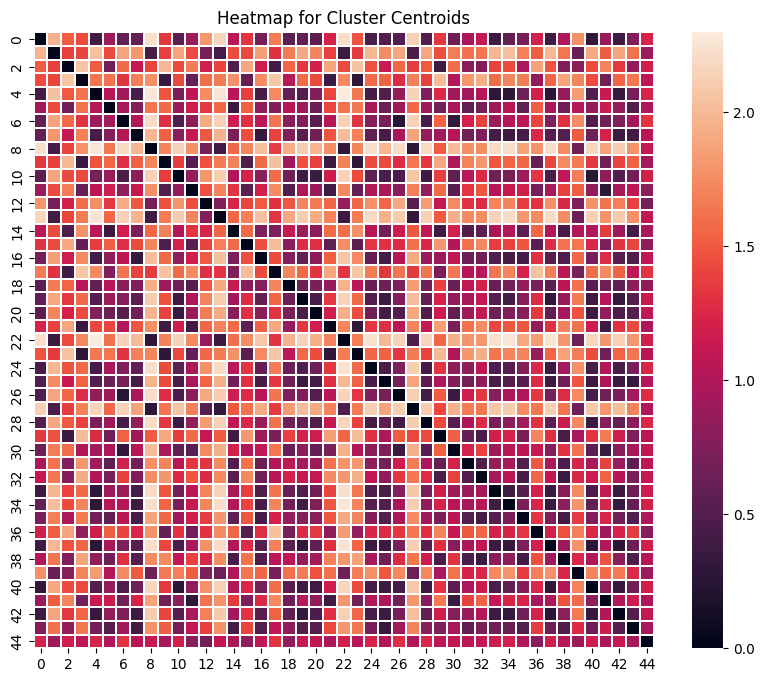

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(centers_distances, linewidths=.2);
plt.title('Heatmap for Cluster Centroids')
plt.show()

In [ ]:
## radar chart
# Create an empty list to store the Scatterpolar object of each cluster
import plotly.graph_objects as go
scatter_objects = []

# State the label for each arm of the chart
categories = clustered_df.columns

# Define the clusters you want to plot
clusters_to_plot = [22, 14, 44]

# Iterate over the unique clusters and add an object for each cluster to the list
#for cluster in sorted(clustered_df['cluster'].unique()):
for cluster in clusters_to_plot:
  # Find the mean value for each column of the cluster
  cluster_means = [clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[0]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[1]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[2]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[3]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[4]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[5]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[6]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[7]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[8]].mean(),
                  clustered_df.loc[clustered_df["cluster"] == cluster, clustered_df.columns[9]].mean()]
                  # Bonus: see if you can turn this code for `cluster_means` into a list comprehension

  # Create a Scatterpolar object for the cluster
  cluster_scatter = go.Scatterpolar(
    r = cluster_means, # set the radial coordinates
    theta = categories, # the names of the columns
    fill = 'toself', # fills in the space with colour
    name = f'Cluster {cluster}' # adds the name of the cluster
  )

  # Add the Scatterpolar object to the list
  scatter_objects.append(cluster_scatter)

# Create the figure (the white area)
fig = go.Figure()

# Add the scatter objects to the figure
fig.add_traces(scatter_objects)

# Add extras to the plot, such as title
fig.update_layout(
  title_text = 'Radar chart of mean songs features by cluster',
  height = 600,
  width = 800,
  polar = dict(
    radialaxis = dict(
      visible = True, # visibility of the numbers on the arm
      range = [0, 1] # scale of the plot
    )),
  showlegend = True
)

# Show the initialised plot and the trace objects
fig.show()

# **18- Evaluation the selective playlists**

In [ ]:
# Extract clusters 14, 22, 44
cluster_14_df = clustered_df[clustered_df['cluster'] == 14].copy()
cluster_22_df = clustered_df[clustered_df['cluster'] == 22].copy()
cluster_44_df = clustered_df[clustered_df['cluster'] == 44].copy()

In [ ]:
cluster_14_df.reset_index(inplace=True)
cluster_22_df.reset_index(inplace=True)
cluster_44_df.reset_index(inplace=True)

In [ ]:
cluster_44_df.columns

Index(['id', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'cluster'],
      dtype='object')

In [ ]:
cluster_14_df

,id,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
0,7BlLxHwobm2gHjXev9dNVe,0.934436,0.215,0.578123,0.255338,0.930723,0.007066,0.064681,0.387817,0.609085,0.028901,14
1,7fnFmtEpfKLnJRkayFeeZ5,0.891003,0.294,0.608497,0.033551,0.906627,0.010964,0.088652,0.240609,0.481429,0.032311,14
2,418er4nP9ZkcjB8oNzTEgb,0.625440,0.566,0.684608,0.024749,0.847892,0.000027,0.063972,0.581726,0.417884,0.019572,14
3,4Zal3Pf8grfpsquXFYe0vK,0.886039,0.451,0.671383,0.033551,0.879518,0.000000,0.062482,0.521827,0.630726,0.020217,14
4,3BCM8JK32QMx7GQpdMPa0w,0.800414,0.267,0.644883,0.054989,0.938253,0.001104,0.078014,0.394924,0.683859,0.018328,14
...,...,...,...,...,...,...,...,...,...,...,...,...
122,7CfuPcDp1GOD0ese4iqgcc,0.606825,0.575,0.692915,0.036514,1.075301,0.000000,0.242553,0.208122,0.559297,0.022726,14
123,2wkiIDEXYJUels0HbBkpvl,0.645295,0.516,0.687568,0.037560,1.049699,0.000000,0.119149,0.293401,0.345666,0.057104,14
124,0RugrGfhtDCfFN4SUwg0th,0.717270,0.474,0.673366,0.034248,0.859940,0.000000,0.078014,0.415228,0.558442,0.034239,14
125,0Toq1jVrrLqQXUGh2Kcn1p,0.683764,0.651,0.734518,0.074946,0.887048,0.000000,0.133333,0.176650,0.487191,0.029026,14


In [ ]:
random_seed = 17
#Randomly sample 3 rows from each cluster DataFrame
sample_14 = cluster_14_df.sample(3, random_state=random_seed)
sample_22= cluster_22_df.sample(3, random_state=random_seed)
sample_44 = cluster_44_df.sample(3, random_state=random_seed)

In [ ]:
sample_14

,level_0,index,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
67,67,67,0.791727,0.352,0.661654,0.023355,0.740964,0.000000,0.074468,0.207107,0.440081,0.022633,14
52,52,52,0.544778,0.488,0.593864,0.053595,1.057229,0.000516,0.113475,0.638579,0.434679,0.036447,14
66,66,66,0.967942,0.565,0.687033,0.026667,1.108434,0.004096,0.044681,0.370558,0.476504,0.038246,14


In [ ]:
sample_22

,id,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
67,3sLgMuBTIEp761Zi7bl5im,0.142709,0.00150,0.293059,0.041046,1.477410,1.442132,0.067021,0.034924,0.314734,0.082377,22
52,3Q6okpLoq2ZhOzZfBHpmei,0.078304,0.00256,0.203371,0.039390,1.471386,1.279188,0.081560,0.023756,0.308047,0.075183,22
66,7JcGySsJWYeAxESN63zowD,0.193588,0.09450,0.490548,0.037908,1.253012,1.373604,0.069078,0.066701,0.306963,0.026097,22


In [ ]:
sample_44

,id,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
44,0JUzvFNKXoONetORLPoRS4,0.759462,0.382,0.652877,0.026405,0.284639,1.041624,0.055461,0.175635,0.586826,0.012676,44
16,6TlLq2hP4KtTLiEp8MYmS4,0.613030,0.268,0.644205,0.026928,0.558735,0.589340,0.087943,0.478173,0.803720,0.040932,44
21,2JXzKmttRH5Hj1Q587ParV,0.817787,0.649,0.575345,0.058126,0.706325,0.679188,0.090780,0.980711,0.432067,0.011816,44


# **19- creating real playlists in spotify**

In [ ]:
!pip install spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 6.8 MB/s eta 0:00:00


In [ ]:
import spotipy
import pickle
from spotipy.oauth2 import SpotifyOAuth
from spotipy.oauth2 import SpotifyClientCredentials
from google.colab import userdata # only in Google Colab for secret management

In [ ]:
scope = 'playlist-modify-public'
username = '31264ukizgmaciinhbjklxkml5ei'
redirectUri = 'https://example.com/callback/'
client_id = '4574c597da814454a26a1d179bfc99b5'
client_secret = '3e7d924ee326454e9f240f3a2cbc338d'

token = SpotifyOAuth(scope=scope,
                     username=username,
                     client_id=client_id,
                     client_secret=client_secret,
                     redirect_uri=redirectUri,
                     open_browser=False # this line is need in Colab, but not on local machine
                     )
spotifyObject = spotipy.Spotify(auth_manager = token)

In [ ]:
playlist_collection = {}
n_playlists= [cluster_14_df, cluster_22_df, cluster_44_df]

for i in range(len(n_playlists)):  # This range must match the number of playlists
    playlist_name = f'my_playlist_cluster_{i+1}'  # Here, we will create simple playlist names indicating which cluster created the playlist
    playlist_description= 'this is a test list'
    playlist_id = spotifyObject.user_playlist_create(user= username,
                                                     name=playlist_name,
                                                     public=True,
                                                     description=playlist_description)['id']
    id_list = list(n_playlists[i]
                            .sample(5)  # Here, we simply take 5 songs randomly from each cluster
                            .id
                   )
     # Spotify needs cetain text wrappers around ID numbers to identify the target as a track, a playlist, etc.
    uris = [f'spotify:track:{str(id).strip()}' for id in id_list]
    spotifyObject.user_playlist_add_tracks(user=username,playlist_id=playlist_id,tracks=uris)
    playlist_collection[playlist_name] = playlist_id

# When this code is run, either a browser window will open, or in Google Colab a URL will appear
# This URL will ask you to sign in to Spotify
# After signing in, copy the URL you are redirected to and paste it in the box that pops up

In [ ]:
# Playlist IDs can be saved for later
with open("./playlists.pkl", "wb") as f:
    pickle.dump(playlist_collection, f)

# This step is only needed in Google Colab
from google.colab import files